In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.models import load_model
from keras.layers import Dense, LSTM
from keras.callbacks import EarlyStopping
import joblib

In [14]:
# Stock symbol
stock = "GOOG"

# Time range: last 20 years
end = datetime.now()
start = datetime(end.year - 20, end.month, end.day)

# Download data
google_data = yf.download(stock, start=start, end=end, auto_adjust=False, progress=False)

# Check for valid data
if google_data.empty:
    raise ValueError("No data returned. Check ticker or network connection.")
if 'Adj Close' not in google_data.columns:
    raise ValueError("'Adj Close' column is missing. Try again later or check ticker.")


Price     Adj Close        Close         High          Low         Open  \
Ticker         GOOG         GOOG         GOOG         GOOG         GOOG   
count   5033.000000  5033.000000  5033.000000  5033.000000  5033.000000   
mean      51.291684    51.513031    52.042631    50.968944    51.491956   
std       48.824185    49.000641    49.530413    48.469698    48.973159   
min        5.510398     5.536498     5.571616     5.484692     5.525539   
25%       13.634324    13.698903    13.868268    13.537010    13.698654   
50%       28.938110    29.075174    29.283602    28.900154    29.119055   
75%       71.077835    71.414497    71.980499    70.492500    71.424500   
max      207.473633   207.710007   208.699997   204.259995   204.500000   

Price         Volume  
Ticker          GOOG  
count   5.033000e+03  
mean    1.019776e+08  
std     1.315673e+08  
min     1.584340e+05  
25%     2.602800e+07  
50%     4.747328e+07  
75%     1.243965e+08  
max     1.650833e+09  
<class 'pandas.core

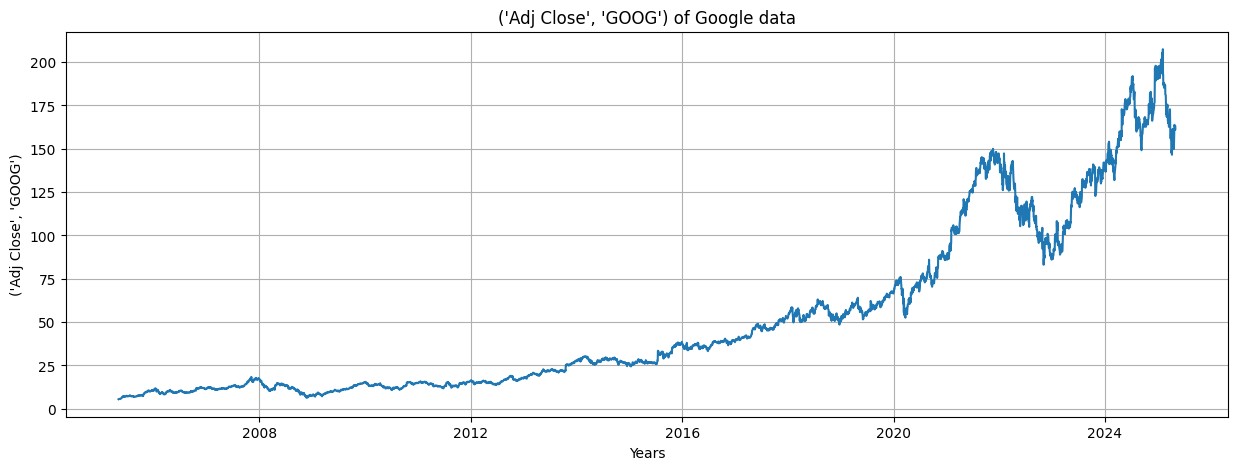

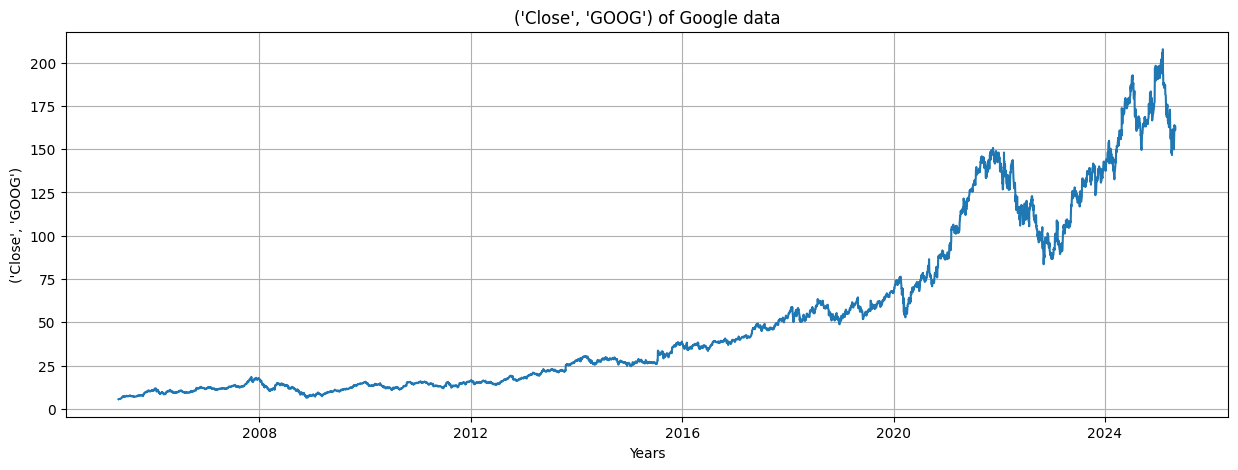

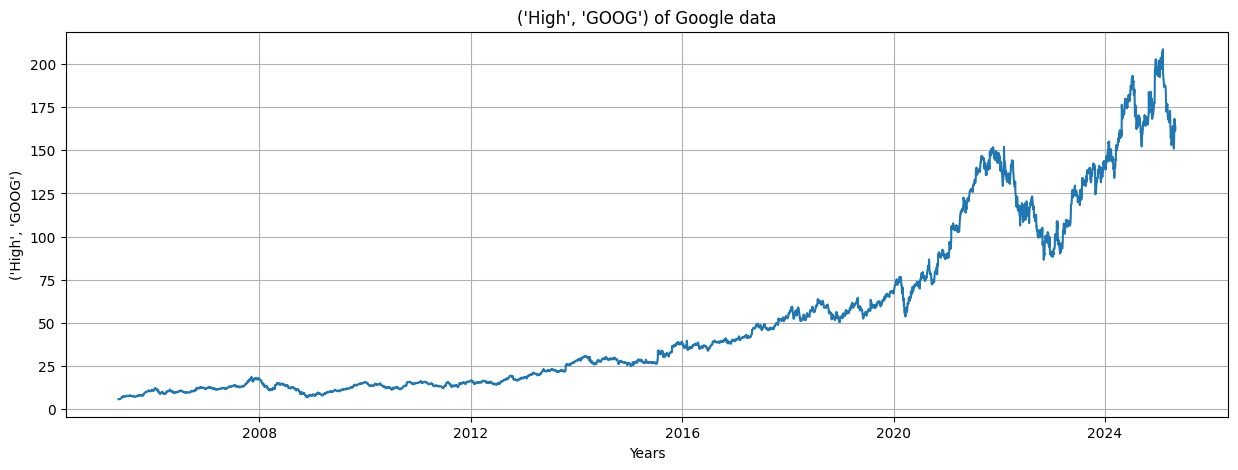

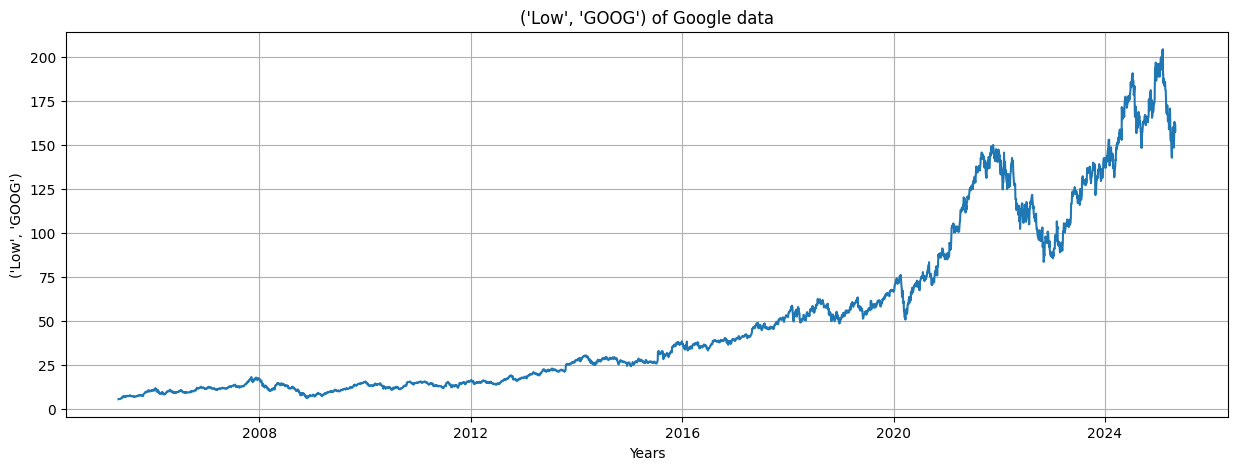

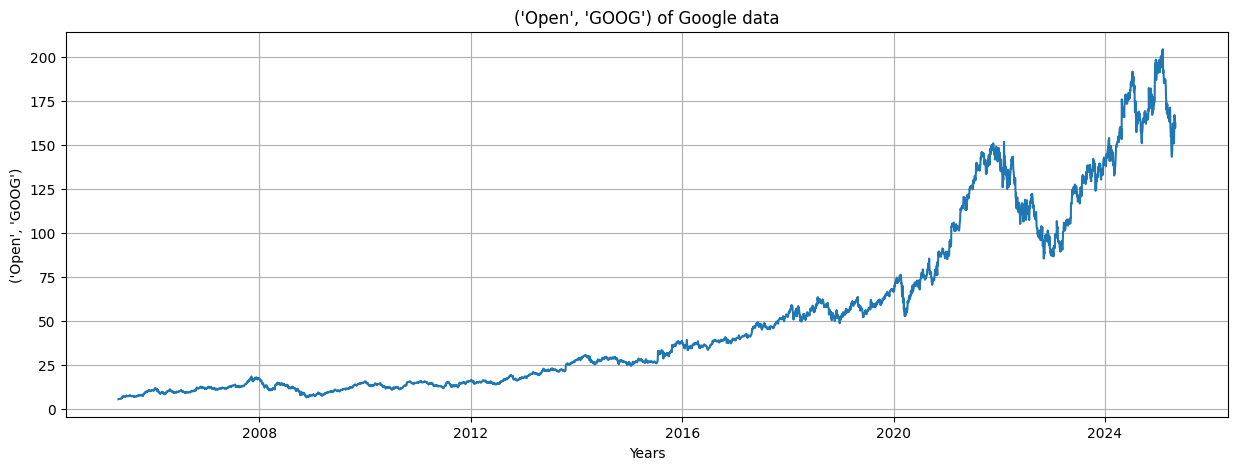

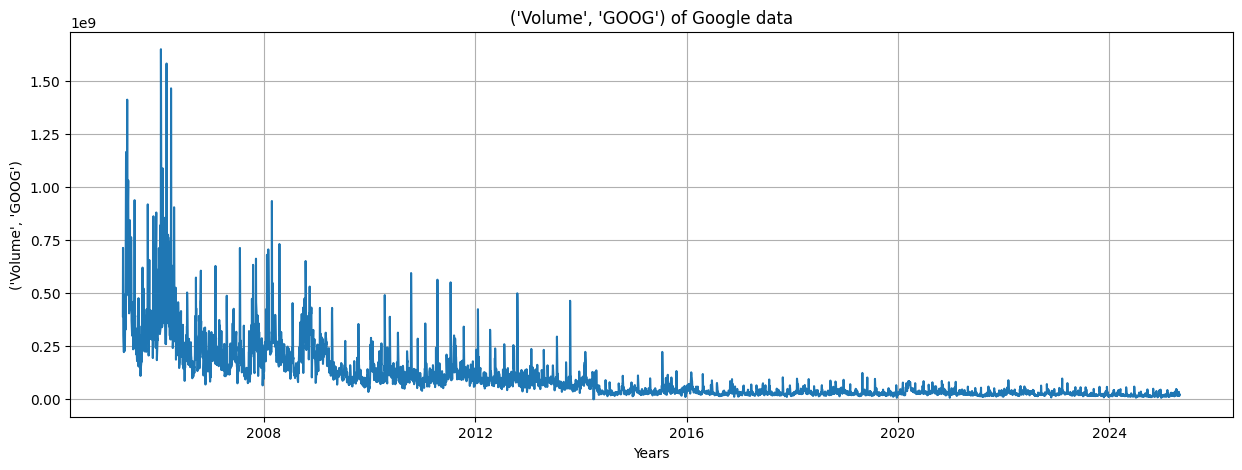

In [15]:
# Display basic info
print(google_data.describe())
print(google_data.info())
print(google_data.isna().sum())

# Plotting function
def plot_graph(figsize, values, column_name):
    plt.figure(figsize=figsize)
    if isinstance(values, pd.DataFrame):
        for col in values.columns:
            plt.plot(values[col], label=col)
        plt.legend()
    else:
        plt.plot(values)
    plt.xlabel("Years")
    plt.ylabel(column_name)
    plt.title(f"{column_name} of Google data")
    plt.grid(True)
    plt.show()

# Plot all columns
for column in google_data.columns:
    plot_graph((15, 5), google_data[column], column)

C:\Users\Predator\AppData\Local\Temp\ipykernel_21508\621517886.py:11: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(values[col], label=col)


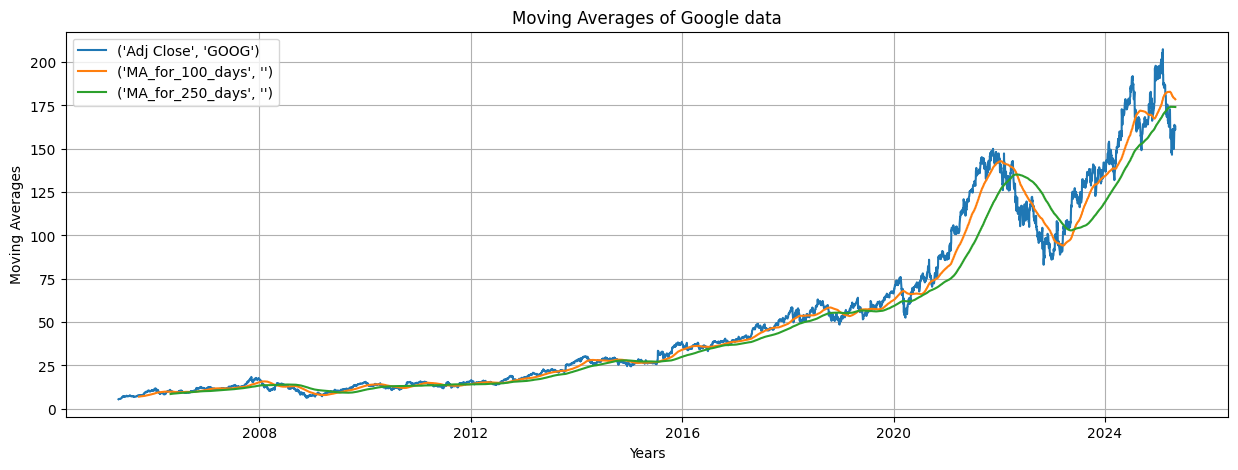

In [16]:
# Moving averages
google_data['MA_for_100_days'] = google_data['Adj Close'].rolling(100).mean()
google_data['MA_for_250_days'] = google_data['Adj Close'].rolling(250).mean()

# Plot moving averages
plot_graph((15, 5), google_data[['Adj Close', 'MA_for_100_days', 'MA_for_250_days']], 'Moving Averages')

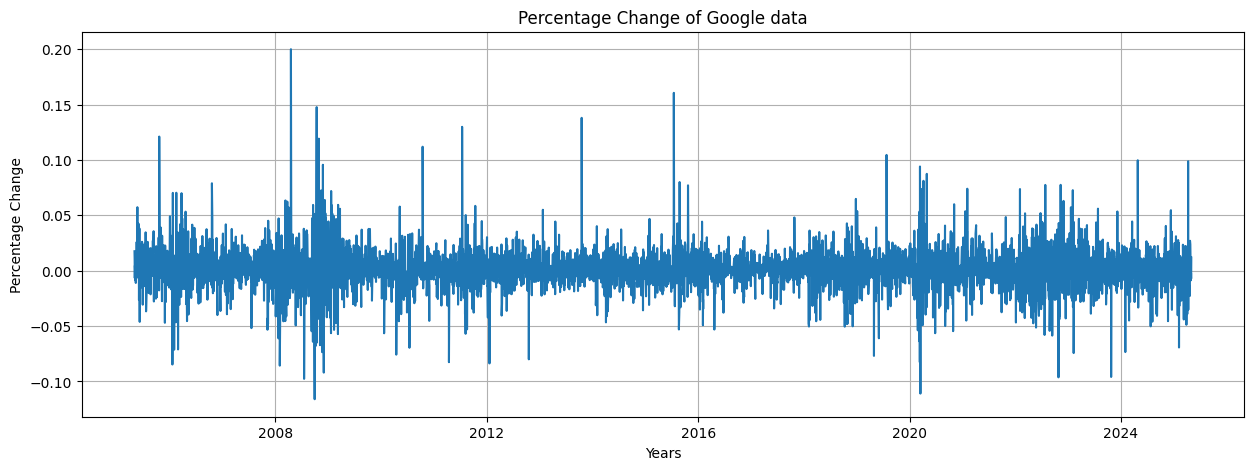

In [17]:
# Percentage change
google_data['percentage_change_cp'] = google_data['Adj Close'].pct_change()
plot_graph((15, 5), google_data['percentage_change_cp'], 'Percentage Change')


In [18]:
# Prepare data
Adj_close_price = google_data[['Adj Close']].dropna()

# Normalize
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(Adj_close_price)

# Sequence creation
x_data, y_data = [], []
for i in range(100, len(scaled_data)):
    x_data.append(scaled_data[i-100:i])
    y_data.append(scaled_data[i])

x_data, y_data = np.array(x_data), np.array(y_data)
x_data = x_data.reshape((x_data.shape[0], x_data.shape[1], 1))

# Split train/test
split_len = int(len(x_data) * 0.7)
x_train, y_train = x_data[:split_len], y_data[:split_len]
x_test, y_test = x_data[split_len:], y_data[split_len:]

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)


Train: (3453, 100, 1) (3453, 1)
Test : (1480, 100, 1) (1480, 1)


In [19]:
# Build model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    LSTM(64, return_sequences=False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train model
early_stop = EarlyStopping(monitor='loss', patience=3)
model.fit(x_train, y_train, batch_size=32, epochs=10, callbacks=[early_stop])
model.summary()

Epoch 1/10
108/108 [==============================] - 15s 91ms/step - loss: 3.7521e-04
Epoch 2/10
108/108 [==============================] - 10s 92ms/step - loss: 2.2351e-05
Epoch 3/10
108/108 [==============================] - 9s 84ms/step - loss: 2.1378e-05
Epoch 4/10
108/108 [==============================] - 9s 86ms/step - loss: 2.3770e-05
Epoch 5/10
108/108 [==============================] - 9s 80ms/step - loss: 2.3534e-05
Epoch 6/10
108/108 [==============================] - 8s 77ms/step - loss: 2.1907e-05
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 100, 128)          66560     
                                                                 
 lstm_3 (LSTM)               (None, 64)                49408     
                                                                 
 dense_2 (Dense)             (None, 25)                1625     

In [20]:
# Predictions
predictions = model.predict(x_test)
inv_predictions = scaler.inverse_transform(predictions)
inv_y_test = scaler.inverse_transform(y_test)

# RMSE
rmse = np.sqrt(np.mean((inv_predictions - inv_y_test) ** 2))
print(f"RMSE: {rmse}")

47/47 [==============================] - 3s 37ms/step
RMSE: 6.091416228582808


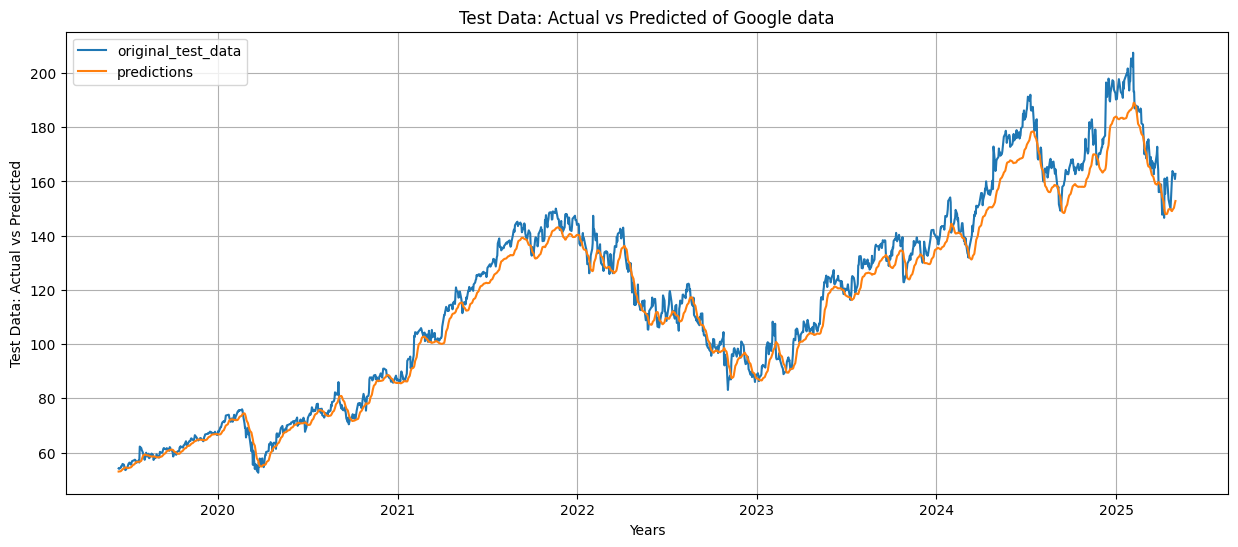

C:\Users\Predator\AppData\Local\Temp\ipykernel_21508\621517886.py:11: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(values[col], label=col)


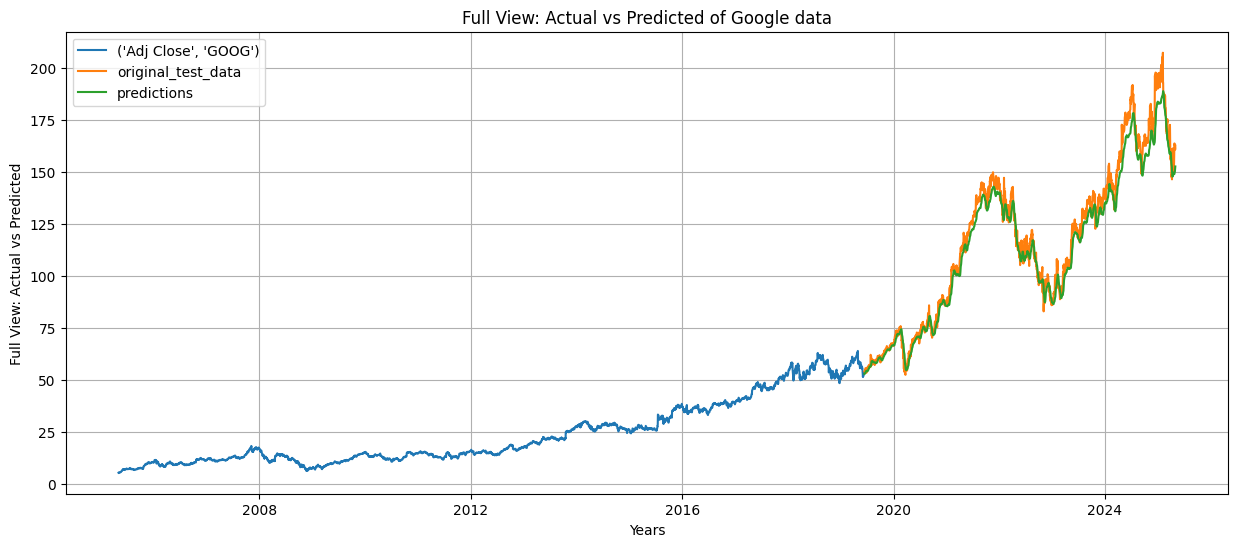

In [21]:
# Plot predictions
ploting_data = pd.DataFrame({
    'original_test_data': inv_y_test.reshape(-1),
    'predictions': inv_predictions.reshape(-1)
}, index=Adj_close_price.index[split_len + 100:])

plot_graph((15, 6), ploting_data, 'Test Data: Actual vs Predicted')

# Full view
combined = pd.concat([Adj_close_price[:split_len + 100], ploting_data], axis=0)
plot_graph((15, 6), combined, 'Full View: Actual vs Predicted')


In [22]:
# Save model and scaler
#model.save("Latest_stock_price_model.keras")
model = load_model("Latest_stock_price_model.keras", compile=False)
joblib.dump(scaler, "price_scaler.pkl")

['price_scaler.pkl']